In [19]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# 
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Country-data (1).csv')

### Preperation

In [14]:
# df = df.set_index('country')

# Scale all columns
scaled_array = StandardScaler().fit_transform(df)
df_scaled = pd.DataFrame(scaled_array, columns=df.columns, index=df.index)
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
Albania,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
Algeria,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
Angola,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
Antigua and Barbuda,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


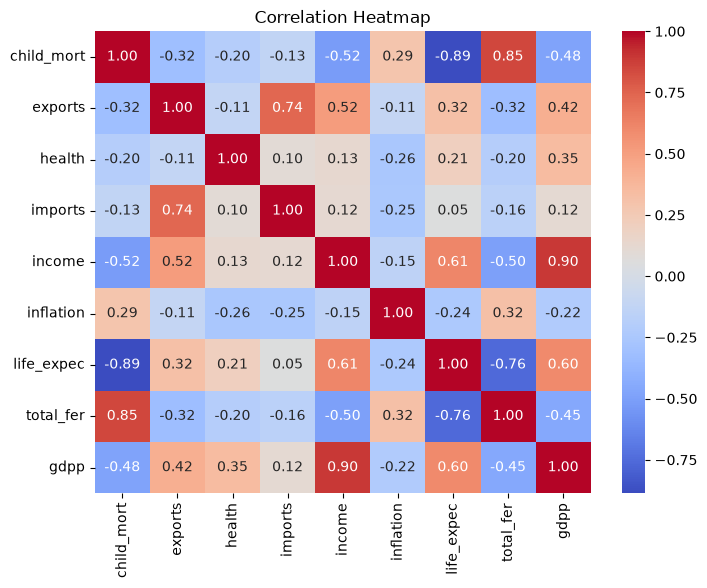

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Pca

In [16]:
# Fit PCA on all components first to see variance explained
pca = PCA()
pca.fit(df_scaled)

# Check cumulative explained variance
cumulative_var = pca.explained_variance_ratio_.cumsum()
print(cumulative_var)

[0.4595174  0.63133365 0.76137624 0.87190786 0.94530998 0.97015232
 0.98275663 0.99256944 1.        ]


In [17]:
n_components = 3
pca_final = PCA(n_components=n_components)
pca_data = pca_final.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'], index=df_scaled.index)
pca_df.head()

,PC1,PC2,PC3
country,,,
Afghanistan,-2.913025,0.095621,-0.718118
Albania,0.429911,-0.588156,-0.333486
Algeria,-0.285225,-0.455174,1.221505
Angola,-2.932423,1.695555,1.525044
Antigua and Barbuda,1.033576,0.136659,-0.225721


### K-means & Silhouette

In [20]:
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_data)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_data, labels))

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={i:.2f}, silhouette={s:.3f}")

k=2: inertia=698.24, silhouette=0.349
k=3: inertia=550.21, silhouette=0.372
k=4: inertia=442.08, silhouette=0.309
k=5: inertia=377.78, silhouette=0.289
k=6: inertia=330.54, silhouette=0.306
k=7: inertia=286.42, silhouette=0.311


In [27]:
# Final Model is being cluster=3 , column cluster for countries 
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(pca_data)

df['kmeans_cluster'] = kmeans_labels
df['kmeans_cluster'].value_counts()

kmeans_cluster
1    94
0    70
2     3
Name: count, dtype: int64

In [28]:
cluster_profile = df.groupby('kmeans_cluster')[['child_mort','income','gdpp','life_expec','total_fer']].mean()
print(cluster_profile)

                child_mort        income          gdpp  life_expec  total_fer
kmeans_cluster                                                               
0                74.278571   4521.900000   2168.914286   62.280000   4.343143
1                12.544681  25048.191489  19579.680851   76.371277   1.959043
2                 4.133333  64033.333333  57566.666667   81.433333   1.380000


In [29]:
label_map = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}
df['development_status'] = df['kmeans_cluster'].map(label_map)

df['development_status'].value_counts()

development_status
Developing        94
Underdeveloped    70
Developed          3
Name: count, dtype: int64

In [30]:
df[df['kmeans_cluster'] == 2]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,development_status
country,,,,,,,,,,,
Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000,2,Developed
Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100,2,Developed
Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600,2,Developed


### Hierarchical Clustering

In [34]:
Z = linkage(pca_data, method='ward')

hier_labels = fcluster(Z, t=3, criterion='maxclust')

df['hier_cluster'] = hier_labels
df['hier_cluster'].value_counts()

pd.crosstab(df['kmeans_cluster'], df['hier_cluster'])

hier_cluster,1,2,3
kmeans_cluster,,,
0,57,0,13
1,7,0,87
2,0,3,0


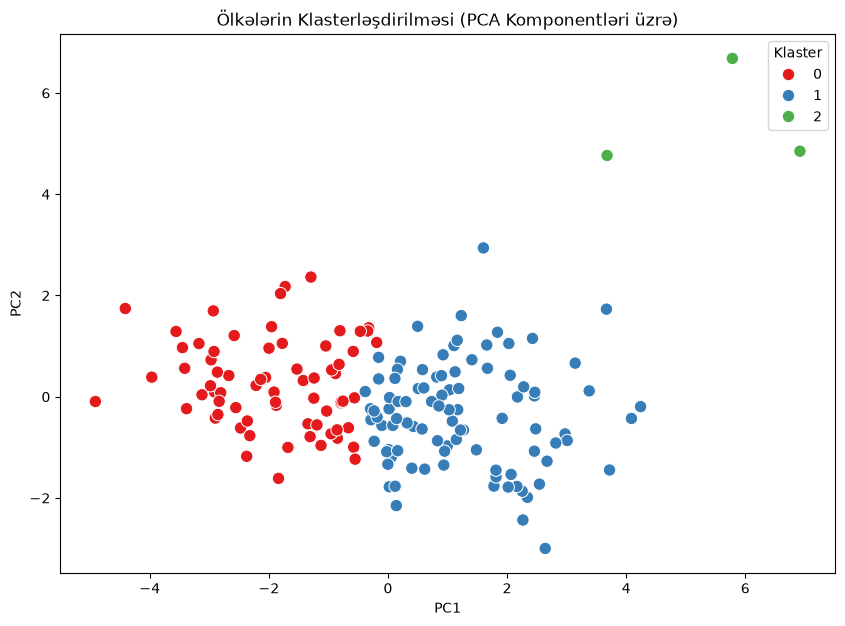

In [35]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df['kmeans_cluster'], palette='Set1', s=80)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Ölkələrin Klasterləşdirilməsi (PCA Komponentləri üzrə)')
plt.legend(title='Klaster')
plt.show()